In [25]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler  # Import for standardizing features (zero mean, unit variance)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset # for loading data in batches
from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix # Custom utility
from tqdm import tqdm

In [2]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'
subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results
torch.manual_seed(RANDOM_STATE)

EPOCHS = 101 # number of epochs
BATCH_SIZE = 32
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2
TRAIN_SIZE = 452 * BATCH_SIZE

# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
data_df = pd.read_csv('fifa_2019.csv')
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 89 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                18207 non-null  int64  
 1   ID                        18207 non-null  int64  
 2   Name                      18207 non-null  object 
 3   Age                       18207 non-null  int64  
 4   Photo                     18207 non-null  object 
 5   Nationality               18207 non-null  object 
 6   Flag                      18207 non-null  object 
 7   Overall                   18207 non-null  int64  
 8   Potential                 18207 non-null  int64  
 9   Club                      17966 non-null  object 
 10  Club Logo                 18207 non-null  object 
 11  Value                     18207 non-null  object 
 12  Wage                      18207 non-null  object 
 13  Special                   18207 non-null  int64  
 14  Prefer

In [5]:
# Following columns appear to be relevant for our analysis
rel_cols = ["Position", 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
            'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
            'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
            'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
            'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
            'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
            'GKKicking', 'GKPositioning', 'GKReflexes']

goalkeeper = 'GK'
forward = ['ST', 'LW', 'RW', 'LF', 'RF', 'RS','LS', 'CF']
midfielder = ['CM','RCM','LCM', 'CDM','RDM','LDM', 'CAM', 'LAM', 'RAM', 'RM', 'LM']
defender = ['CB', 'RCB', 'LCB', 'LWB', 'RWB', 'LB', 'RB']

In [6]:
data_df = data_df[rel_cols]
data_df = data_df[data_df['Position'].notnull()]
data_df.info(), data_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 18147 entries, 0 to 18206
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Position         18147 non-null  object 
 1   Finishing        18147 non-null  float64
 2   HeadingAccuracy  18147 non-null  float64
 3   ShortPassing     18147 non-null  float64
 4   Volleys          18147 non-null  float64
 5   Dribbling        18147 non-null  float64
 6   Curve            18147 non-null  float64
 7   FKAccuracy       18147 non-null  float64
 8   LongPassing      18147 non-null  float64
 9   BallControl      18147 non-null  float64
 10  Acceleration     18147 non-null  float64
 11  SprintSpeed      18147 non-null  float64
 12  Agility          18147 non-null  float64
 13  Reactions        18147 non-null  float64
 14  Balance          18147 non-null  float64
 15  ShotPower        18147 non-null  float64
 16  Jumping          18147 non-null  float64
 17  Stamina          

(None,
 Position           0
 Finishing          0
 HeadingAccuracy    0
 ShortPassing       0
 Volleys            0
 Dribbling          0
 Curve              0
 FKAccuracy         0
 LongPassing        0
 BallControl        0
 Acceleration       0
 SprintSpeed        0
 Agility            0
 Reactions          0
 Balance            0
 ShotPower          0
 Jumping            0
 Stamina            0
 Strength           0
 LongShots          0
 Aggression         0
 Interceptions      0
 Positioning        0
 Vision             0
 Penalties          0
 Composure          0
 Marking            0
 StandingTackle     0
 SlidingTackle      0
 GKDiving           0
 GKHandling         0
 GKKicking          0
 GKPositioning      0
 GKReflexes         0
 dtype: int64)

In [7]:
data_df.loc[data_df['Position'] == "GK", 'Position'] = 0
data_df.loc[data_df['Position'].isin(defender), 'Position'] = 1
data_df.loc[data_df['Position'].isin(midfielder), 'Position'] = 2
data_df.loc[data_df['Position'].isin(forward), 'Position'] = 3

data_df['Position'] = pd.to_numeric(data_df['Position'], downcast='integer') # to int8 else it was int64

data_df.dtypes

Position              int8
Finishing          float64
HeadingAccuracy    float64
ShortPassing       float64
Volleys            float64
Dribbling          float64
Curve              float64
FKAccuracy         float64
LongPassing        float64
BallControl        float64
Acceleration       float64
SprintSpeed        float64
Agility            float64
Reactions          float64
Balance            float64
ShotPower          float64
Jumping            float64
Stamina            float64
Strength           float64
LongShots          float64
Aggression         float64
Interceptions      float64
Positioning        float64
Vision             float64
Penalties          float64
Composure          float64
Marking            float64
StandingTackle     float64
SlidingTackle      float64
GKDiving           float64
GKHandling         float64
GKKicking          float64
GKPositioning      float64
GKReflexes         float64
dtype: object

In [8]:
class_labels = {
    0: 'Goal Keeper', 
    1: 'Defender',
    2: 'Mid-fielder',
    3: 'Forward'
}

In [9]:
# labels = data_df['Position']
# features_df = data_df.drop('Position', axis=1)
# features_df.shape, labels.shape 


In [10]:
train_df, test_df = train_test_split(data_df, 
                                        # test_size=TEST_SIZE, 
                                        train_size=TRAIN_SIZE,
                                        random_state=RANDOM_STATE, 
                                        stratify=data_df['Position'])

train_df.shape, test_df.shape

((14464, 34), (3683, 34))

### Custom Dataset

Singleton design pattern

In [11]:
# make sure that there will be only one StandardScaler   --- Singleton Class. 
# Cannot create two objects of this class
class GlobalScaler:
    _instance = None # single underscore _ does not mean anything, just for convention <Glo........>

    def __init__(self):
        if GlobalScaler._instance is not None:
            raise Exception ('GlobalScaler is Singleton Class')
        
        self.scaler = StandardScaler()

    # singleton pattern --- not instantiating using GlobalScaler()
    @classmethod
    def get_instance(cls):
        if cls._instance is None:
            cls._instance = GlobalScaler()
        return cls._instance

In [12]:

class FifaDS(Dataset):
    global_scaler = GlobalScaler.get_instance() # protected variable _instance, so use getter

    def __init__(self, dataframe, device = device, 
                        is_train = True, label_col = None):
        self.df = dataframe
        self.device = device
        self.is_train = is_train
        self.scaler = self.global_scaler.scaler   # we can use FifaDS.global_scaler in place of self.global_scaler
        self.label_col = label_col
    
        self.labels = self.df[label_col].to_numpy()  # dataframe to numpy
        
        if self.is_train:
            X = self.df.drop(label_col, axis=1)            
            self.features = self.scaler.fit_transform(X)
        else:           
            X = self.df.drop(label_col, axis=1)          # for testing data
            self.features = self.scaler.transform(X)    
        
    def __len__(self): # len of dataframe
        return len(self.features)
    
    def __getitem__(self, index): # return torch tensor
        feature = self.features[index]
        label = self.labels[index]

        feature = torch.tensor(feature, dtype=torch.float32, device=self.device)
        label = torch.tensor(label, dtype=torch.int64, device=device)
        return feature, label
    
    

In [13]:
train_df = train_df.reset_index(drop=True)
train_df.head()

,Position,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,2,66.0,34.0,71.0,48.0,74.0,69.0,64.0,68.0,70.0,...,56.0,68.0,13.0,22.0,26.0,8.0,14.0,6.0,6.0,12.0
1,1,29.0,61.0,59.0,28.0,55.0,47.0,30.0,54.0,58.0,...,36.0,38.0,55.0,62.0,58.0,6.0,13.0,14.0,12.0,11.0
2,3,72.0,42.0,73.0,73.0,76.0,83.0,84.0,72.0,74.0,...,85.0,77.0,42.0,21.0,20.0,10.0,7.0,14.0,7.0,10.0
3,2,63.0,48.0,66.0,40.0,70.0,65.0,55.0,64.0,69.0,...,44.0,68.0,57.0,57.0,52.0,12.0,9.0,5.0,8.0,13.0
4,2,28.0,40.0,53.0,33.0,48.0,39.0,34.0,42.0,47.0,...,35.0,37.0,62.0,40.0,49.0,8.0,12.0,8.0,12.0,5.0


In [14]:
test_df = test_df.reset_index(drop=True)
test_df.head()

,Position,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,2,47.0,37.0,62.0,52.0,56.0,59.0,54.0,56.0,53.0,...,56.0,54.0,35.0,31.0,32.0,11.0,6.0,5.0,8.0,6.0
1,1,57.0,73.0,75.0,38.0,74.0,61.0,40.0,67.0,74.0,...,46.0,73.0,78.0,78.0,78.0,13.0,9.0,10.0,15.0,16.0
2,1,41.0,66.0,57.0,26.0,38.0,31.0,41.0,26.0,47.0,...,48.0,53.0,71.0,67.0,71.0,8.0,6.0,6.0,13.0,10.0
3,2,43.0,65.0,70.0,69.0,71.0,69.0,68.0,67.0,70.0,...,66.0,71.0,63.0,66.0,71.0,11.0,8.0,13.0,12.0,15.0
4,1,23.0,48.0,42.0,22.0,23.0,27.0,24.0,23.0,32.0,...,32.0,43.0,55.0,52.0,53.0,10.0,10.0,14.0,6.0,12.0


In [15]:
label_col = 'Position'
train_ds = FifaDS(train_df, is_train=True, label_col=label_col)
test_ds = FifaDS(test_df, is_train=False, label_col=label_col)

In [16]:
type(train_df), type(train_ds), type(test_df), type(test_ds)

(pandas.core.frame.DataFrame,
 __main__.FifaDS,
 pandas.core.frame.DataFrame,
 __main__.FifaDS)

In [17]:
for count, data in enumerate(train_ds):
    feat, lbl = data
    print(f'Count: {count} | {feat.shape}, {lbl}')

Count: 0 | torch.Size([33]), 2
Count: 1 | torch.Size([33]), 1
Count: 2 | torch.Size([33]), 3
Count: 3 | torch.Size([33]), 2
Count: 4 | torch.Size([33]), 2
Count: 5 | torch.Size([33]), 1
Count: 6 | torch.Size([33]), 1
Count: 7 | torch.Size([33]), 2
Count: 8 | torch.Size([33]), 2
Count: 9 | torch.Size([33]), 0
Count: 10 | torch.Size([33]), 1
Count: 11 | torch.Size([33]), 1
Count: 12 | torch.Size([33]), 0
Count: 13 | torch.Size([33]), 1
Count: 14 | torch.Size([33]), 2
Count: 15 | torch.Size([33]), 2
Count: 16 | torch.Size([33]), 2
Count: 17 | torch.Size([33]), 0
Count: 18 | torch.Size([33]), 3
Count: 19 | torch.Size([33]), 2
Count: 20 | torch.Size([33]), 3
Count: 21 | torch.Size([33]), 1
Count: 22 | torch.Size([33]), 2
Count: 23 | torch.Size([33]), 2
Count: 24 | torch.Size([33]), 2
Count: 25 | torch.Size([33]), 2
Count: 26 | torch.Size([33]), 3
Count: 27 | torch.Size([33]), 1
Count: 28 | torch.Size([33]), 1
Count: 29 | torch.Size([33]), 0
Count: 30 | torch.Size([33]), 3
Count: 31 | torch.

In [18]:
for count, data in enumerate(test_ds):
    feat, lbl = data
    print(f'Count: {count} | {feat.shape}, {lbl}')

Count: 0 | torch.Size([33]), 2
Count: 1 | torch.Size([33]), 1
Count: 2 | torch.Size([33]), 1
Count: 3 | torch.Size([33]), 2
Count: 4 | torch.Size([33]), 1
Count: 5 | torch.Size([33]), 1
Count: 6 | torch.Size([33]), 2
Count: 7 | torch.Size([33]), 1
Count: 8 | torch.Size([33]), 1
Count: 9 | torch.Size([33]), 2
Count: 10 | torch.Size([33]), 2
Count: 11 | torch.Size([33]), 3
Count: 12 | torch.Size([33]), 0
Count: 13 | torch.Size([33]), 1
Count: 14 | torch.Size([33]), 3
Count: 15 | torch.Size([33]), 2
Count: 16 | torch.Size([33]), 3
Count: 17 | torch.Size([33]), 1
Count: 18 | torch.Size([33]), 3
Count: 19 | torch.Size([33]), 3
Count: 20 | torch.Size([33]), 1
Count: 21 | torch.Size([33]), 2
Count: 22 | torch.Size([33]), 3
Count: 23 | torch.Size([33]), 1
Count: 24 | torch.Size([33]), 3
Count: 25 | torch.Size([33]), 2
Count: 26 | torch.Size([33]), 0
Count: 27 | torch.Size([33]), 2
Count: 28 | torch.Size([33]), 1
Count: 29 | torch.Size([33]), 1
Count: 30 | torch.Size([33]), 3
Count: 31 | torch.

The values are coming as single rows, use dataloader to get batches.

In [19]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True) # dataloader will give batches
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)
for count, data in enumerate(train_loader):
    feat, lbl = data
    print(f'Count: {count} | {feat.shape}, {lbl}')


Count: 0 | torch.Size([32, 33]), tensor([2, 1, 1, 1, 3, 1, 2, 2, 2, 1, 2, 1, 2, 0, 3, 0, 1, 1, 2, 1, 2, 2, 1, 2,
        0, 3, 2, 1, 3, 3, 3, 2])
Count: 1 | torch.Size([32, 33]), tensor([0, 3, 2, 1, 1, 1, 0, 1, 3, 2, 3, 1, 2, 1, 2, 2, 3, 1, 3, 1, 3, 1, 1, 3,
        2, 1, 0, 3, 1, 2, 1, 2])
Count: 2 | torch.Size([32, 33]), tensor([2, 2, 2, 3, 1, 2, 3, 2, 1, 1, 0, 0, 1, 2, 1, 2, 0, 1, 3, 1, 3, 0, 3, 1,
        1, 2, 2, 3, 2, 2, 3, 0])
Count: 3 | torch.Size([32, 33]), tensor([2, 2, 3, 2, 0, 2, 3, 1, 2, 3, 2, 0, 1, 3, 2, 1, 1, 0, 2, 1, 0, 1, 3, 2,
        3, 2, 2, 0, 2, 2, 1, 2])
Count: 4 | torch.Size([32, 33]), tensor([1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 3, 1, 0, 1,
        2, 2, 0, 3, 2, 3, 3, 3])
Count: 5 | torch.Size([32, 33]), tensor([2, 1, 1, 2, 3, 2, 0, 0, 1, 0, 1, 1, 0, 2, 1, 1, 3, 3, 2, 2, 1, 3, 1, 2,
        2, 1, 0, 0, 1, 0, 2, 2])
Count: 6 | torch.Size([32, 33]), tensor([2, 2, 3, 1, 1, 2, 3, 1, 0, 2, 3, 1, 2, 1, 1, 2, 1, 2, 3, 3, 1, 0, 2, 1,
        2, 

Defining torch model

In [23]:
class Model(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        # first layer  -- gets input
        out_dim_1 = 66
        self.layer1 = nn.Linear(input_dim, out_dim_1)   # output 66
        self.actv1 = nn.ReLU()

        # second layer
        out_dim_2 = 33
        self.layer2 = nn.Linear(out_dim_1, out_dim_2)   # output 33
        self.actv2 = nn.ReLU()

        # third layer
        out_dim_3 = 16
        self.layer3 = nn.Linear(out_dim_2, out_dim_3)   # output 16
        self.actv3 = nn.ReLU()

        # fourth layer
        out_dim_4 = 8
        self.layer4 = nn.Linear(out_dim_3, out_dim_4)   # output 8
        self.actv4 = nn.ReLU()

        # fifth layer -- gives outputs
        self.layer5 = nn.Linear(out_dim_4, 4)           # output 4

    
    # forward propagation
    def forward(self, x):
        x = self.actv1(self.layer1(x))
        x = self.actv2(self.layer2(x))
        x = self.actv3(self.layer3(x))
        x = self.actv4(self.layer4(x))
        x = self.layer5(x)
        return x
    

model = Model(input_dim=33).to(device=device)
print(model)
        

Model(
  (layer1): Linear(in_features=33, out_features=66, bias=True)
  (actv1): ReLU()
  (layer2): Linear(in_features=66, out_features=33, bias=True)
  (actv2): ReLU()
  (layer3): Linear(in_features=33, out_features=16, bias=True)
  (actv3): ReLU()
  (layer4): Linear(in_features=16, out_features=8, bias=True)
  (actv4): ReLU()
  (layer5): Linear(in_features=8, out_features=4, bias=True)
)


In [51]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=ALPHA)

loss, test_loss = [], []
acc, test_acc = [], []
n_epoch = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for i, data in enumerate(train_loader):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        batch_loss = loss_fn(outputs, labels)
        batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())

        batch_loss.backward()
        optimizer.step()
        train_loss += batch_loss.item() * inputs.size(0)
        train_acc += batch_acc * inputs.size(0)

    train_loss = train_loss/len(train_ds)
    train_acc = train_acc/len(train_ds)
    loss.append(train_loss)
    acc.append(train_acc)


    # testing now
    with torch.no_grad():
        model.eval()
        tst_loss = 0.0
        tst_acc = 0.0

        for i, data in enumerate(test_loader):
            inputs, labels = data
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            batch_loss = loss_fn(outputs, labels)
            batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())

            tst_loss += batch_loss.item() * inputs.size(0)
            tst_acc += batch_acc * inputs.size(0)

        tst_loss = tst_loss/len(test_ds)
        tst_acc = tst_acc/len(test_ds)
        test_loss.append(tst_loss)
        test_acc.append(tst_acc)

    n_epoch.append(epoch)

    if epoch%10 == 0: 
        print(f'Epoch {epoch}: loss = {train_loss:.4f}, accuracy = {train_acc:.3f}'+
                        f', val_loss = {tst_loss:.4f}, val_accuracy = {tst_acc:.3f}')
        
        

Epoch 0: loss = 0.0643, accuracy = 0.977, val_loss = 1.1471, val_accuracy = 0.833
Epoch 10: loss = 0.0536, accuracy = 0.981, val_loss = 1.1995, val_accuracy = 0.829
Epoch 20: loss = 0.0513, accuracy = 0.982, val_loss = 1.2431, val_accuracy = 0.839
Epoch 30: loss = 0.0543, accuracy = 0.980, val_loss = 1.3120, val_accuracy = 0.836
Epoch 40: loss = 0.0625, accuracy = 0.978, val_loss = 1.3024, val_accuracy = 0.838
Epoch 50: loss = 0.0632, accuracy = 0.977, val_loss = 1.3684, val_accuracy = 0.834
Epoch 60: loss = 0.0479, accuracy = 0.982, val_loss = 1.4538, val_accuracy = 0.834
Epoch 70: loss = 0.0290, accuracy = 0.990, val_loss = 1.5426, val_accuracy = 0.837
Epoch 80: loss = 0.0291, accuracy = 0.991, val_loss = 1.5744, val_accuracy = 0.836
Epoch 90: loss = 0.0480, accuracy = 0.983, val_loss = 1.5826, val_accuracy = 0.838
Epoch 100: loss = 0.0252, accuracy = 0.992, val_loss = 1.6599, val_accuracy = 0.835


In [52]:
model_history_df = pd.DataFrame({'epoch':n_epoch,
                                 'loss':loss,
                                 'test_loss':test_loss,
                                 'acc':train_acc,
                                 'test_acc':test_acc})
model_history_df.head()

,epoch,loss,test_loss,acc,test_acc
0,0,0.064303,1.147124,0.992257,0.833017
1,1,0.058950,1.154643,0.992257,0.833831
2,2,0.068628,1.136192,0.992257,0.832474
3,3,0.049633,1.172609,0.992257,0.836003
4,4,0.064774,1.122498,0.992257,0.827043


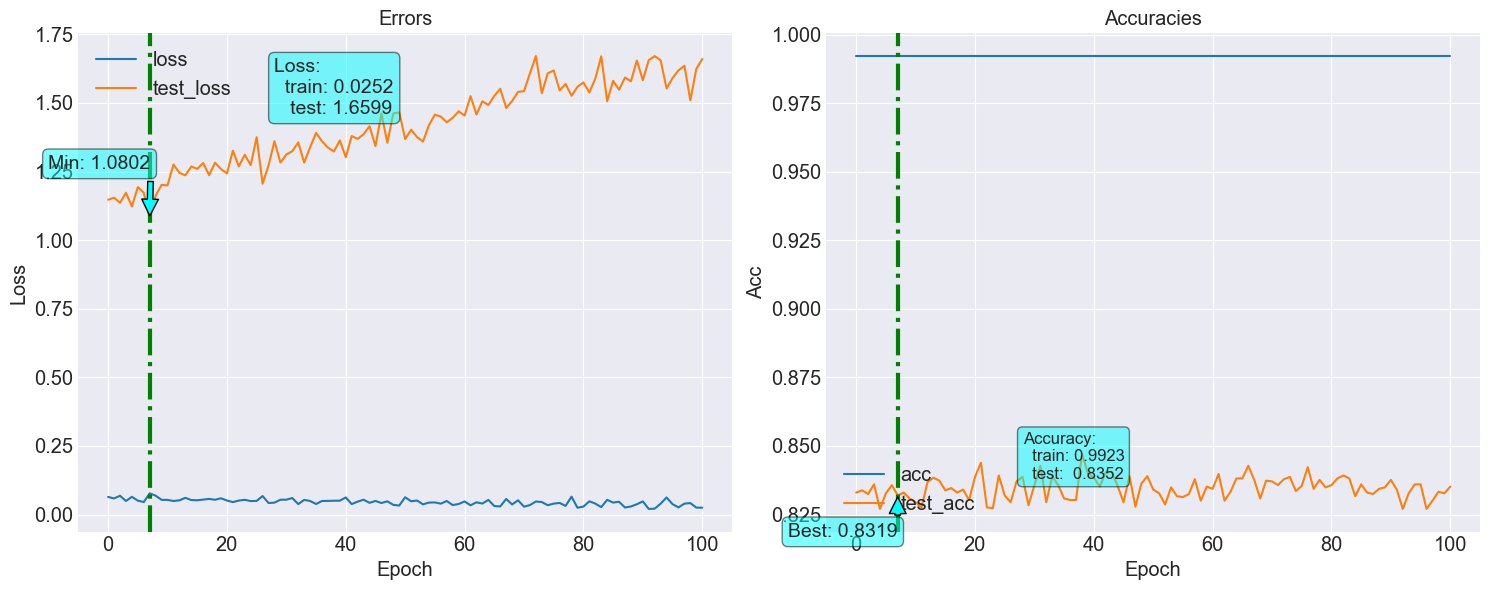

In [53]:
fn_plot_torch_hist(model_history_df)

Predictions

Training set

In [56]:
y_true, y_pred = [], []

for feat, lbls in train_loader:
    pred = model(feat).detach().cpu().numpy()
    y_true.extend(lbls.cpu().numpy())
    y_pred.extend(pred.argmax(axis=1))

print(f'Accuracy: {accuracy_score(y_true, y_pred)}')
print(classification_report(y_true, y_pred))

Accuracy: 0.9908047566371682
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1614
           1       1.00      1.00      1.00      4676
           2       1.00      0.98      0.99      5450
           3       0.97      0.99      0.98      2724

    accuracy                           0.99     14464
   macro avg       0.99      0.99      0.99     14464
weighted avg       0.99      0.99      0.99     14464



Test set

In [57]:
y_true, y_pred = [], []

for feat, lbls in test_loader:
    pred = model(feat).detach().cpu().numpy()
    y_true.extend(lbls.cpu().numpy())
    y_pred.extend(pred.argmax(axis=1))

print(f'Accuracy: {accuracy_score(y_true, y_pred)}')
print(classification_report(y_true, y_pred))

Accuracy: 0.8351887048601684
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       411
           1       0.89      0.90      0.90      1190
           2       0.79      0.77      0.78      1388
           3       0.72      0.76      0.74       694

    accuracy                           0.84      3683
   macro avg       0.85      0.86      0.85      3683
weighted avg       0.84      0.84      0.84      3683

